# BERT Embeddings & VADER Sentiment for Reddit Comments

This notebook uses BERT for tokenization and [CLS] embedding extraction, and VADER for 3-class sentiment analysis (positive/neutral/negative) on Reddit comment data from the Sentimentrix project.

## Goals:
1. Load Reddit comments data
2. Extract BERT [CLS] embeddings for each comment
3. Apply VADER 3-class sentiment labeling
4. Visualize VADER sentiment distribution

## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if device == 0 else 'CPU'}")

Device: GPU


## Step 2: Load Data

In [3]:
# Load all comment datasets and combine them
from pathlib import Path

data_dir = Path("../data/processed")
all_comments = []

for file_name in data_dir.rglob("*_comments_processed.csv"):
    df = pd.read_csv(file_name)
    df['source_subreddit'] = file_name.stem[:-19]  # Extract subreddit name (remove '_comments_processed')
    all_comments.append(df)
    print(f"Loaded {len(df)} comments from {file_name.stem}")

D_westernu_comments = pd.concat(all_comments, ignore_index=True)
print(f"\nTotal comments combined: {len(D_westernu_comments)}")
print(f"Total subreddits: {D_westernu_comments['source_subreddit'].nunique()}")
display(D_westernu_comments.head())

Loaded 3148 comments from DIY_comments_processed
Loaded 11583 comments from space_comments_processed
Loaded 14717 comments from science_comments_processed
Loaded 9718 comments from EatCheapAndHealthy_comments_processed
Loaded 7435 comments from pics_comments_processed
Loaded 7626 comments from history_comments_processed
Loaded 9532 comments from foodhacks_comments_processed
Loaded 5120 comments from memes_comments_processed
Loaded 6749 comments from BikiniBottomTwitter_comments_processed
Loaded 15521 comments from books_comments_processed
Loaded 7443 comments from Steam_comments_processed
Loaded 7204 comments from PremierLeague_comments_processed
Loaded 15682 comments from HistoryMemes_comments_processed
Loaded 12265 comments from funny_comments_processed
Loaded 3551 comments from Daytrading_comments_processed
Loaded 846 comments from Art_comments_processed
Loaded 5187 comments from anime_irl_comments_processed
Loaded 3928 comments from ChatGPT_comments_processed
Loaded 4382 comments f

,post_id,comment_id,comment_text,comment_score,comment_author,comment_created_utc,parent_id,reply_to_id,comment_sentiment,has_images,num_images,image_urls,subreddit,sentiment_scores,compound,source_subreddit
0,1nnqhc3,nfmcswl,sup yall\n\nI installed some nice 60/70 lb cab...,1.0,J_Schnetz,1758557338.0,t3_1nnqhc3,1nnqhc3,positive,False,0,NaN,DIY,"{'neg': 0.074, 'neu': 0.815, 'pos': 0.111, 'co...",0.5423,DIY
1,1nnqhc3,nfnr1fm,How do I best remove these to replace with bla...,1.0,torsemide,1758572409.0,t3_1nnqhc3,1nnqhc3,positive,False,0,NaN,DIY,"{'neg': 0.0, 'neu': 0.704, 'pos': 0.296, 'comp...",0.6369,DIY
2,1nnqhc3,nfqjnxh,Door handle issues https://imgur.com/a/MBJ0TKL...,1.0,WootheDave,1758618590.0,t3_1nnqhc3,1nnqhc3,negative,False,0,NaN,DIY,"{'neg': 0.088, 'neu': 0.858, 'pos': 0.054, 'co...",-0.2263,DIY
3,1nnqhc3,ng01mu7,Just bought a semi commercial ice maker and pl...,1.0,YearZero_,1758741934.0,t3_1nnqhc3,1nnqhc3,neutral,False,0,NaN,DIY,"{'neg': 0.029, 'neu': 0.939, 'pos': 0.031, 'co...",0.0460,DIY
4,1nhpvp1,neetjqx,Does anyone know how to hang these flat art wo...,2.0,orbit0317,1757969066.0,t3_1nhpvp1,1nhpvp1,positive,False,0,NaN,DIY,"{'neg': 0.0, 'neu': 0.883, 'pos': 0.117, 'comp...",0.5719,DIY


## Step 3: Data Preprocessing

In [4]:
# Data preprocessing with gentler filtering
# Minimum comment length to keep (set to 2 to avoid dropping short but valid comments)
MIN_LEN = 2

# Ensure text column exists; try common alternatives if not
text_col = None
for candidate in ['comment_text', 'body', 'text', 'commentBody']:
    if candidate in D_westernu_comments.columns:
        text_col = candidate
        break

if text_col is None:
    raise KeyError(f'No text column found in comments CSV. Columns: {D_westernu_comments.columns.tolist()}')

print('Using text column:', text_col)

# Create cleaned DataFrame
D_comments_clean = D_westernu_comments.dropna(subset=[text_col]).copy()
D_comments_clean[text_col] = D_comments_clean[text_col].astype(str).str.strip()
# Remove empty strings
D_comments_clean = D_comments_clean[D_comments_clean[text_col].str.len() >= MIN_LEN].copy()
# Rename to standard column used downstream
D_comments_clean = D_comments_clean.rename(columns={text_col: 'comment_text'})

print(f"Original rows: {len(D_westernu_comments)}, after dropna and min length ({MIN_LEN}): {len(D_comments_clean)}")
# show sample
display(D_comments_clean[['comment_id', 'comment_text']].head())

Using text column: comment_text
Original rows: 954307, after dropna and min length (2): 953007


,comment_id,comment_text
0,nfmcswl,sup yall\n\nI installed some nice 60/70 lb cab...
1,nfnr1fm,How do I best remove these to replace with bla...
2,nfqjnxh,Door handle issues https://imgur.com/a/MBJ0TKL...
3,ng01mu7,Just bought a semi commercial ice maker and pl...
4,neetjqx,Does anyone know how to hang these flat art wo...


## Step 4: Initialize BERT Pipeline

## Step 4b: Load BERT Tokenizer and Model for Embeddings

We'll use the BERT tokenizer and model to extract [CLS] embeddings for each comment. This will NOT perform sentiment classification, only feature extraction.

In [5]:
from transformers import BertTokenizer, BertModel
import torch

# Load BERT tokenizer and model
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
bert_model = BertModel.from_pretrained(MODEL_NAME)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)
bert_model.eval()
print(f"BERT model loaded on {device}")

BERT model loaded on cuda


In [49]:
# Extract [CLS] embeddings for all comments in batches
from tqdm.notebook import tqdm

BATCH_SIZE = 16
MAX_LENGTH = 128
texts = D_comments_clean['comment_text'].astype(str).tolist()[:20000]  # Limit to first 20000 comments for demo
all_cls_embeddings = []

print(f"Extracting BERT [CLS] embeddings for {len(texts)} comments...")
for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]
    inputs = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = bert_model(**inputs)
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_cls_embeddings.append(cls_emb)

# Concatenate all embeddings
import numpy as np
bert_cls_matrix = np.concatenate(all_cls_embeddings, axis=0)
print(f"bert_cls_matrix shape: {bert_cls_matrix.shape}")

# Optionally, add to DataFrame for downstream ML
# D_comments_clean['bert_cls_embedding'] = list(bert_cls_matrix)

Extracting BERT [CLS] embeddings for 20000 comments...


  0%|          | 0/1250 [00:00<?, ?it/s]

bert_cls_matrix shape: (20000, 768)


In [78]:
# Extract Mean Pooled embeddings (Much better than [CLS] for frozen BERT)
from tqdm.notebook import tqdm

BATCH_SIZE = 32
MAX_LENGTH = 128
texts = D_comments_clean['comment_text'].astype(str).tolist()[:20000]
all_embeddings = []

print(f"Extracting Mean Pooled BERT embeddings for {len(texts)} comments...")

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i+BATCH_SIZE]
    inputs = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = bert_model(**inputs)
        
        # Mean Pooling Strategy
        token_embeddings = outputs.last_hidden_state # Shape: [batch, seq_len, 768]
        attention_mask = inputs['attention_mask']
        
        # Expand mask to match embedding dimensions
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
        # Sum embeddings (ignoring padding) and divide by token count
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask
        
        all_embeddings.append(mean_pooled.cpu().numpy())

# Concatenate
bert_cls_matrix = np.concatenate(all_embeddings, axis=0)
print(f"Embeddings shape: {bert_cls_matrix.shape}")

Extracting Mean Pooled BERT embeddings for 20000 comments...


  0%|          | 0/625 [00:00<?, ?it/s]

Embeddings shape: (20000, 768)


## Step 5: VADER Sentiment Labeling

In [50]:
# VADER sentiment labeling for all comments
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if not isinstance(text, str):
        return 'neutral'
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

D_comments_clean['vader_sentiment'] = D_comments_clean['comment_text'][:20000].apply(get_vader_sentiment)
print(D_comments_clean['vader_sentiment'].value_counts())

vader_sentiment
positive    9782
negative    5470
neutral     4748
Name: count, dtype: int64


## Step 6: Results (VADER Only)

In [51]:
print("VADER Sentiment Distribution:")
print(D_comments_clean['vader_sentiment'].value_counts())

VADER Sentiment Distribution:
vader_sentiment
positive    9782
negative    5470
neutral     4748
Name: count, dtype: int64


## Step 7: Visualization (VADER Sentiment)

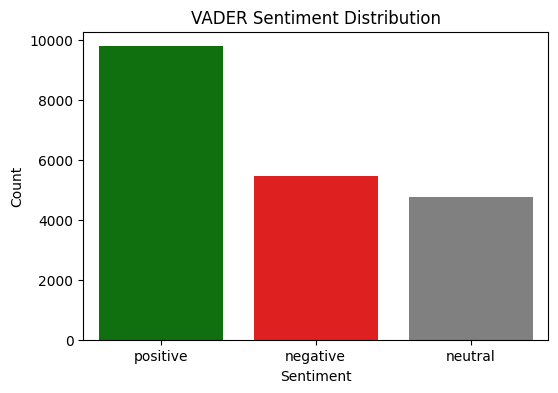

In [52]:
# Visualize VADER sentiment distribution
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = D_comments_clean['vader_sentiment'].value_counts()
colors = ['green' if x == 'positive' else 'red' if x == 'negative' else 'gray' for x in sentiment_counts.index]
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)
plt.title('VADER Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## Step 8: Benchmarking

In [79]:
# Step 8: Benchmarking
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.calibration import label_binarize
from sklearn.metrics import roc_curve, auc, confusion_matrix
import numpy as np
import pandas as pd

# Prepare data - use BERT embeddings as features and VADER sentiment as labels
X = bert_cls_matrix  # BERT CLS embeddings (768-dimensional)
y = D_comments_clean['vader_sentiment'].values[:20000]

print(f"Total samples: {len(X)}")
print(f"Feature dimensions: {X.shape[1]}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}")


# Scale the Data (Crucial for SVM performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Total samples: 20000
Feature dimensions: 768
Class distribution:
positive    9782
negative    5470
neutral     4748
Name: count, dtype: int64


In [80]:
# 70-15-15 train-val-test split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")


Training set: 14000 samples
Validation set: 3000 samples
Test set: 3000 samples


In [81]:
# Train SVM classifier on BERT embeddings
print("\nTraining SVM classifier on BERT embeddings...")
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=100, random_state=42)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

# 4. Train with Grid Search
print("Training SVM with PCA...")
param_grid = {
    'svm__C': [1, 10],
    'svm__gamma': ['scale', 0.01]
}

# Use 3-fold cross validation and grid search with a linear kernel 
grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV F1-Score: {grid.best_score_:.4f}")
model = grid.best_estimator_


Training SVM classifier on BERT embeddings...
Training SVM with PCA...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters: {'svm__C': 1, 'svm__gamma': 'scale'}
Best CV F1-Score: 0.6249


In [82]:
# Get all unique labels
all_labels = sorted(np.unique(y))

# Evaluate on training set
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(classification_report(y_train, y_train_pred, labels=all_labels, zero_division=0))


Training Accuracy: 0.7819
              precision    recall  f1-score   support

    negative       0.68      0.81      0.74      3829
     neutral       0.77      0.86      0.81      3324
    positive       0.87      0.73      0.79      6847

    accuracy                           0.78     14000
   macro avg       0.77      0.80      0.78     14000
weighted avg       0.79      0.78      0.78     14000



In [83]:
# Evaluate on validation set
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print(classification_report(y_val, y_val_pred, labels=all_labels, zero_division=0))


Validation Accuracy: 0.6093
              precision    recall  f1-score   support

    negative       0.49      0.59      0.54       821
     neutral       0.57      0.66      0.61       712
    positive       0.73      0.60      0.66      1467

    accuracy                           0.61      3000
   macro avg       0.60      0.61      0.60      3000
weighted avg       0.63      0.61      0.61      3000



In [84]:
# Evaluate on test set
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, y_test_pred, labels=all_labels, zero_division=0))


Test Accuracy: 0.6063
              precision    recall  f1-score   support

    negative       0.51      0.61      0.55       820
     neutral       0.55      0.66      0.60       712
    positive       0.73      0.58      0.65      1468

    accuracy                           0.61      3000
   macro avg       0.60      0.62      0.60      3000
weighted avg       0.63      0.61      0.61      3000



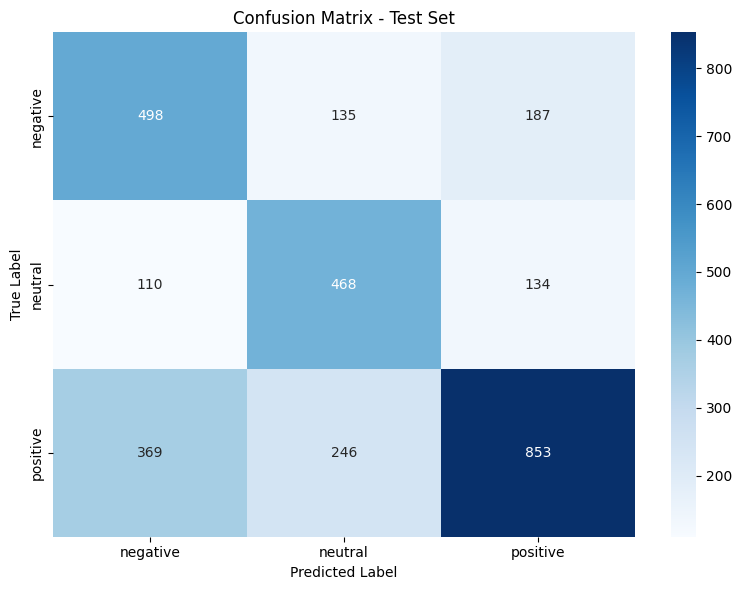


Confusion Matrix (Test Set):
Labels: ['negative', 'neutral', 'positive']
[[498 135 187]
 [110 468 134]
 [369 246 853]]


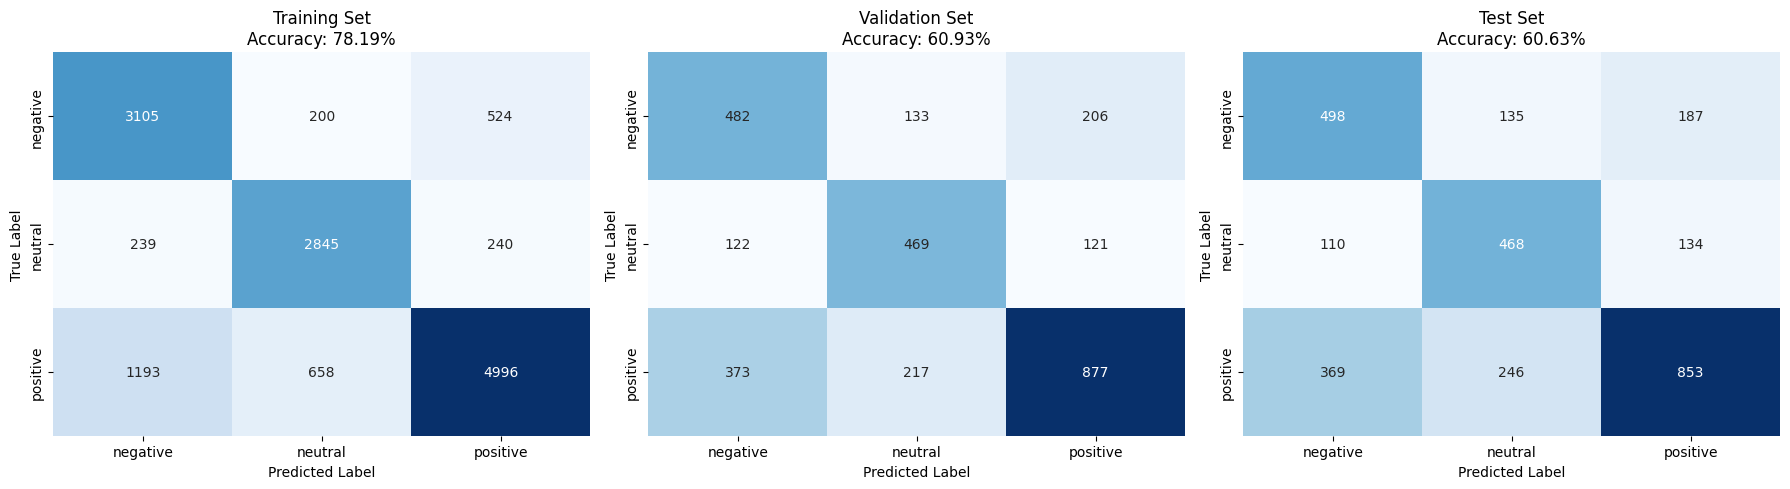

In [85]:
# Generate confusion matrix for test set
cm = confusion_matrix(y_test, y_test_pred, labels=all_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,           # Show numbers in cells
    fmt='d',              # Integer format
    cmap='Blues',         # Color scheme
    xticklabels=all_labels,
    yticklabels=all_labels,
    cbar=True
)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print confusion matrix as text
print("\nConfusion Matrix (Test Set):")
print(f"Labels: {all_labels}")
print(cm)

# Optional: Generate for all splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training set
cm_train = confusion_matrix(y_train, y_train_pred, labels=all_labels)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=all_labels, yticklabels=all_labels, 
            ax=axes[0], cbar=False)
axes[0].set_title(f'Training Set\nAccuracy: {train_accuracy:.2%}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Validation set
cm_val = confusion_matrix(y_val, y_val_pred, labels=all_labels)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_labels, yticklabels=all_labels,
            ax=axes[1], cbar=False)
axes[1].set_title(f'Validation Set\nAccuracy: {val_accuracy:.2%}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Test set
cm_test = confusion_matrix(y_test, y_test_pred, labels=all_labels)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_labels, yticklabels=all_labels,
            ax=axes[2], cbar=False)
axes[2].set_title(f'Test Set\nAccuracy: {test_accuracy:.2%}')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()
